<a href="https://colab.research.google.com/github/goumze/Simplilearn_Agentic_AI/blob/feature%2Fcollab/OpenAI_LangGraph_Based_NewsGenie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📰 NewsGenie – AI-Powered News & Information Assistant

An end-to-end implementation using:

| Component | Technology |
|---|---|
| Workflow orchestration | **LangGraph** state machine |
| Language model | **OpenAI GPT-3.5-turbo** via LangChain |
| Real-time news | **NewsAPI** |
| Web search (fallback) | **DuckDuckGo** (no API key needed) |
| Interactive UI | **Streamlit** |

## Architecture
```
User Query
    │
    ▼
classify_query  ← LLM decides: news or general
    │
 ┌──┴──┐
 ▼     ▼
fetch_ web_
news   search
 │     │
 └──┬──┘
    ▼
generate_response  ← LLM formats final answer
    │
    ▼
Answer / News Cards
```

In [ ]:
pip install requests==2.32.5

In [ ]:
%pip install -q --upgrade langchain langchain-openai langchain-community langgraph \
             streamlit newsapi-python duckduckgo-search python-dotenv

## Step 1 — Configure API Keys

- **NewsAPI key** – free account at <https://newsapi.org/register>  
- **OpenAI key** – <https://platform.openai.com/api-keys>

Enter them in the cell below (input is hidden via `getpass`).

In [ ]:
import os
from getpass import getpass
from google.colab import userdata


_news_key   = userdata.get('NEWS_API_KEY')
_openai_key = userdata.get('OPENAI_API_KEY')

if _news_key:   os.environ['NEWS_API_KEY']   = _news_key
if _openai_key: os.environ['OPENAI_API_KEY'] = _openai_key

# Also try loading a .env file if present
try:
    from dotenv import load_dotenv
    load_dotenv(override=False)
except ImportError:
    pass

news_ok   = bool(os.getenv('NEWS_API_KEY',   '').strip())
openai_ok = bool(os.getenv('OPENAI_API_KEY', '').strip())
print(f"NewsAPI key  : {'set' if news_ok   else 'NOT SET'}")
print(f"OpenAI key   : {'set' if openai_ok else 'NOT SET'}")

NewsAPI key  : set
OpenAI key   : set


## Step 2 — Tool Definitions

Two tools power the data-fetching nodes:

1. **`get_news()`** – fetches live headlines from NewsAPI (by category or keyword)
2. **`web_search()`** – searches the web via DuckDuckGo (zero-config fallback)

In [ ]:
from typing import Optional
from newsapi import NewsApiClient
from duckduckgo_search import DDGS

NEWS_CATEGORIES = [
    'general', 'technology', 'business', 'sports',
    'health', 'science', 'entertainment',
]

# ── NewsAPI ──────────────────────────────────────────────────────────
def get_news(category: str = 'general',
             query: Optional[str] = None,
             page_size: int = 5) -> list[dict]:
    """Fetch top headlines from NewsAPI.

    Returns a list of article dicts (title, description, url, source,
    published_at). Returns [] on any failure or missing key.
    """
    api_key = os.getenv('NEWS_API_KEY', '').strip()
    if not api_key:
        return []
    client = NewsApiClient(api_key=api_key)
    try:
        if query:
            resp = client.get_everything(
                q=query, language='en', sort_by='relevancy', page_size=page_size)
        else:
            resp = client.get_top_headlines(
                category=category, language='en', page_size=page_size)
        return [
            {'title':        a.get('title', 'No title'),
             'description':  a.get('description') or 'No description.',
             'url':          a.get('url', ''),
             'source':       a.get('source', {}).get('name', 'Unknown'),
             'published_at': a.get('publishedAt', '')}
            for a in resp.get('articles', [])
            if a.get('title') and '[Removed]' not in a.get('title', '')
        ]
    except Exception:
        return []

# ── DuckDuckGo web search ────────────────────────────────────────────
def web_search(query: str, max_results: int = 5) -> str:
    """Search the web via DuckDuckGo and return a formatted string."""
    if not query.strip():
        return 'No query provided.'
    try:
        with DDGS() as ddgs:
            hits = list(ddgs.text(query, max_results=max_results))
        if not hits:
            return 'No relevant results found.'
        lines = []
        for i, r in enumerate(hits, 1):
            lines.append(
                f"{i}. **{r.get('title', 'No title')}**\n"
                f"   {r.get('body', '')}\n"
                f"   Source: {r.get('href', '')}")
        return '\n\n'.join(lines)
    except Exception as exc:
        return f'Web search failed: {exc}'

print('Tools defined: get_news(), web_search()')

Tools defined: get_news(), web_search()


## Step 3 — LangGraph Workflow

The graph has **4 nodes** and one **conditional edge**:

| Node | Purpose |
|---|---|
| `classify_query` | LLM classifies query as `"news"` or `"general"` |
| `fetch_news` | Fetches headlines from NewsAPI |
| `web_search` | Runs DuckDuckGo search |
| `generate_response` | LLM builds the final answer |

In [ ]:
from __future__ import annotations
import json
from typing import Literal
from typing_extensions import TypedDict

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph

# ── Shared LLM helper ────────────────────────────────────────────────
def _llm(temperature: float = 0.3) -> ChatOpenAI:
    return ChatOpenAI(
        model='gpt-3.5-turbo',
        temperature=temperature,
        api_key=os.getenv('OPENAI_API_KEY', ''),
    )

# ── State ────────────────────────────────────────────────────────────
class NewsGenieState(TypedDict):
    query:          str
    category:       str
    query_type:     str
    news_results:   list[dict]
    search_results: str
    response:       str
    error:          Optional[str]

# ── Node 1: classify_query ───────────────────────────────────────────
def classify_query(state: NewsGenieState) -> NewsGenieState:
    system_prompt = (
        'You are a query classifier for a news assistant.\n'
        'Classify the user query as EXACTLY one of:\n'
        '  "news"    — current events, headlines, live scores, market updates\n'
        '  "general" — factual questions, how-to, definitions, history, etc.\n'
        'Reply with ONLY valid JSON, e.g.: {"type": "news"}'
    )
    try:
        resp = _llm(temperature=0).invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=state['query']),
        ])
        result     = json.loads(resp.content.strip())
        query_type = result.get('type', 'general')
        if query_type not in ('news', 'general'):
            query_type = 'general'
    except Exception:
        query_type = 'general'
    return {**state, 'query_type': query_type}

# ── Node 2: fetch_news ───────────────────────────────────────────────
def fetch_news_node(state: NewsGenieState) -> NewsGenieState:
    category = state.get('category', 'general')
    query    = state.get('query', '').strip()
    generic  = {'news', 'headlines', 'latest', 'today', 'top'}
    use_query = bool(set(query.lower().split()) - generic)
    articles = get_news(category=category,
                        query=query if use_query else None,
                        page_size=5)
    error = None
    if not articles:
        error = ('NEWS_API_KEY is not configured.'
                 if not os.getenv('NEWS_API_KEY', '').strip()
                 else 'No articles found. Try a different category or query.')
    return {**state, 'news_results': articles, 'error': error}

# ── Node 3: web_search_node ──────────────────────────────────────────
def web_search_node(state: NewsGenieState) -> NewsGenieState:
    return {**state, 'search_results': web_search(state.get('query', ''))}

# ── Node 4: generate_response ────────────────────────────────────────
def generate_response(state: NewsGenieState) -> NewsGenieState:
    query      = state['query']
    query_type = state.get('query_type', 'general')

    if query_type == 'news':
        articles = state.get('news_results', [])
        if not articles:
            error_hint = state.get('error') or 'No articles retrieved.'
            response = (
                f'No relevant news found. {error_hint}\n\n'
                'Try:\n'
                '  * A different news category\n'
                '  * Rephrasing your query\n'
                '  * Verifying your NEWS_API_KEY'
            )
        else:
            context = '\n\n'.join(
                f"{i}. **{a['title']}** — {a['source']}\n"
                f"   {a['description']}\n"
                f"   URL: {a['url']}\n"
                f"   Published: {a['published_at']}"
                for i, a in enumerate(articles, 1)
            )
            try:
                response = _llm().invoke([
                    SystemMessage(content=(
                        'You are NewsGenie, a concise news assistant. '
                        'Summarise the articles. Highlight key facts and cite sources.'
                    )),
                    HumanMessage(content=f'Query: {query}\n\nArticles:\n{context}'),
                ]).content
            except Exception as exc:
                response = (
                    f'Could not summarise ({exc}).\n\nRaw headlines:\n' +
                    '\n'.join(f"* {a['title']} ({a['source']})" for a in articles)
                )
    else:
        sr = state.get('search_results', '')
        try:
            response = _llm().invoke([
                SystemMessage(content=(
                    'You are NewsGenie, a helpful AI assistant. '
                    'Answer clearly. Use search results as context; '
                    'fall back to general knowledge if unhelpful.'
                )),
                HumanMessage(content=f'Question: {query}\n\nSearch:\n{sr}'),
            ]).content
        except Exception as exc:
            response = f'Could not generate a response ({exc}).'

    return {**state, 'response': response}

# ── Routing ──────────────────────────────────────────────────────────
def route_query(state: NewsGenieState) -> Literal['fetch_news', 'web_search']:
    return 'fetch_news' if state.get('query_type') == 'news' else 'web_search'

# ── Build & compile ──────────────────────────────────────────────────
def build_graph():
    wf = StateGraph(NewsGenieState)
    wf.add_node('classify_query',    classify_query)
    wf.add_node('fetch_news',        fetch_news_node)
    wf.add_node('web_search',        web_search_node)
    wf.add_node('generate_response', generate_response)

    wf.set_entry_point('classify_query')
    wf.add_conditional_edges(
        'classify_query', route_query,
        {'fetch_news': 'fetch_news', 'web_search': 'web_search'},
    )
    wf.add_edge('fetch_news',        'generate_response')
    wf.add_edge('web_search',        'generate_response')
    wf.add_edge('generate_response', END)
    return wf.compile()

graph = build_graph()
print('LangGraph workflow compiled successfully')

LangGraph workflow compiled successfully


## Step 4 — Visualise the Workflow

Renders the state-machine graph as a Mermaid diagram inline.

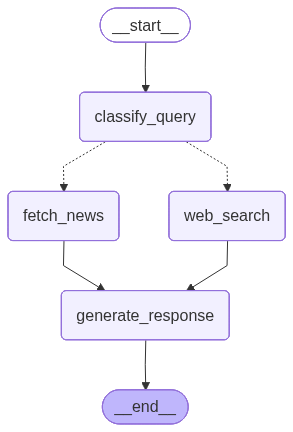

In [ ]:
from IPython.display import display, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: print Mermaid source
    print(graph.get_graph().draw_mermaid())

## Step 5 — Test the Pipeline

Run the full LangGraph workflow against sample queries directly in the notebook.

In [ ]:
def run_newsgenie(query: str, category: str = 'general') -> dict:
    return graph.invoke({
        'query':          query,
        'category':       category,
        'query_type':     '',
        'news_results':   [],
        'search_results': '',
        'response':       '',
        'error':          None,
    })

test_cases = [
    ('What is machine learning?',               'general'),
    ('Show me today\'s top technology headlines', 'technology'),
    ('Latest sports news',                      'sports'),
]

for query, category in test_cases:
    print('=' * 70)
    print(f'Query    : {query}')
    print(f'Category : {category}')
    result = run_newsgenie(query, category)
    print(f'Type     : {result["query_type"]}')
    print()
    print(result['response'])
    if result.get('news_results'):
        print('\nArticles fetched:')
        for a in result['news_results']:
            date = a['published_at'][:10] if a.get('published_at') else ''
            print(f"  * {a['title']} ({a['source']}) — {date}")
    print()

Query    : What is machine learning?
Category : general


/tmp/ipykernel_9799/2826636053.py:48: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use tim

Type     : general

Machine learning is a type of artificial intelligence that allows computers to learn and improve from experience without being explicitly programmed. It involves developing algorithms that can analyze and interpret data to make predictions or decisions. Machine learning is used in various applications such as image recognition, natural language processing, and recommendation systems.

Query    : Show me today's top technology headlines
Category : technology


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Type     : news

**Article: Taylor Lorenz’s Screen Time Is Almost 17 Hours a Day (Wired)**

- Taylor Lorenz, a journalist and content creator, spends almost 17 hours a day on screens.
- She does not follow tech hygiene practices and envisions a world where "inbox infinity" is embraced.
- Source: [Wired](https://www.wired.com/story/user-behavior-taylor-lorenz/)

Articles fetched:
  * Taylor Lorenz’s Screen Time Is Almost 17 Hours a Day (Wired) — 2026-04-01

Query    : Latest sports news
Category : sports


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Type     : news

1. Amazon's Big Spring Sale 2026 is set to run from March 25th to April 1st, with early deals already available. The sale offers various discounts on a range of products. [Source: The Verge]

2. Google TV has introduced new features for sports lovers as part of its Gemini update. The update includes features tailored for deep dives and sports content. [Source: Android Central]

3. The Fox News AI Newsletter highlights the latest advancements in AI technology, including the use of wall-climbing robots swarming US Navy warships. The newsletter covers challenges and opportunities presented by AI. [Source: Fox News]

4. Bigme has teased a new dual-screen E Ink phone powered by Android, featuring an LCD panel. This phone is touted as the world's first of its kind. [Source: Android Central]

5. The Fox News AI Newsletter reports on the FDA's rollout of an AI-powered vaccine platform, showcasing the latest advancements in artificial intelligence technology. The newsletter exp

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Step 6 — Interactive Query

Run a single custom query below.

In [ ]:
# Edit query and category, then run this cell
my_query    = 'Latest AI research news'
my_category = 'technology'

result = run_newsgenie(my_query, my_category)
print(f"Classified as: {result['query_type']}")
print()
print(result['response'])

if result.get('news_results'):
    print('\n--- Source Articles ---')
    for a in result['news_results']:
        print(f"  [{a['source']}] {a['title']}")
        print(f"  {a['url']}")
        print()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Classified as: news

1. OpenAI has decided to halt the release of an erotic chatbot feature called "adult mode" for ChatGPT indefinitely due to internal pushback. This move is part of OpenAI's strategy to focus on its core products. (Source: The Verge)

2. Sony is developing Protective AI technology to prevent copyright infringement by creating an in-house AI system that mimics the style of Studio Ghibli movies. This initiative aims to safeguard creators and rights holders. (Source: Gizmodo.com)

3. A study suggests that while millions of workers in AI-exposed jobs can adapt to changes, around 6 million individuals may face challenges in finding new employment opportunities due to AI-related layoffs. (Source: Gizmodo.com)

4. OpenAI recently announced the discontinuation of its video-generation app, Sora, and the reversal of plans for video generation within ChatGPT. This decision was made following the company's participation in a $1 billion Disney competition. (Source: The Verge)

--

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Step 7 — Launch Streamlit UI

The next two cells write a self-contained `app.py` then start the server.  
Open **http://localhost:8501** in your browser.

In [ ]:
    app_code = """
import os, json
from typing import Optional, Literal

import streamlit as st
from dotenv import load_dotenv
from newsapi import NewsApiClient
from duckduckgo_search import DDGS
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph
from typing_extensions import TypedDict

load_dotenv()

NEWS_CATEGORIES = ['general','technology','business','sports','health','science','entertainment']

def get_news(category='general', query=None, page_size=5):
    api_key = os.getenv('NEWS_API_KEY','').strip()
    if not api_key: return []
    client = NewsApiClient(api_key=api_key)
    try:
        if query:
            resp = client.get_everything(
                q=query, language='en', sort_by='relevancy', page_size=page_size)
        else:
            resp = client.get_top_headlines(
                category=category, language='en', page_size=page_size)
        return [{'title': a.get('title',''), 'description': a.get('description') or '',
                 'url': a.get('url',''), 'source': a.get('source',{}).get('name','Unknown'),
                 'published_at': a.get('publishedAt','')}
                for a in resp.get('articles',[]) if a.get('title') and '[Removed]' not in a.get('title','')}]
    except Exception: return []

def web_search(query, max_results=5):
    if not query.strip(): return 'No query provided.'
    try:
        with DDGS() as d: hits = list(d.text(query, max_results=max_results))
        if not hits: return 'No results found.'
        return chr(10).join(f"{i}. **{r.get('title','')}**\n   {r.get('body','')}\n   {r.get('href','')}"
                            for i,r in enumerate(hits,1))
    except Exception as e: return f'Search failed: {e}'

def _llm(t=0.3): return ChatOpenAI(model='gpt-3.5-turbo', temperature=t,
                                    api_key=os.getenv('OPENAI_API_KEY',''))

class S(TypedDict):
    query:str; category:str; query_type:str
    news_results:list; search_results:str; response:str; error:Optional[str]

def classify_query(s):
    try:
        r = _llm(0).invoke([SystemMessage(content='Classify as news or general. Reply JSON: {\"type\":\"news\"}'),
                            HumanMessage(content=s['query'])])
        qt = json.loads(r.content.strip()).get('type','general')
    except Exception: qt = 'general'
    return {**s, 'query_type': qt if qt in ('news','general') else 'general'}

def fetch_news_node(s):
    q = s.get('query','').strip()
    generic = {'news', 'headlines', 'latest', 'today', 'top'}
    use_q = bool(set(q.lower().split()) - generic)
    arts = get_news(s.get('category','general'), q if use_q else None)
    err = None if arts else ('NEWS_API_KEY not set' if not os.getenv('NEWS_API_KEY','') else 'No articles found')
    return {**s, 'news_results': arts, 'error': err}

def web_search_node(s): return {**s, 'search_results': web_search(s.get('query',''))}

def generate_response(s):
    q, qt = s['query'], s.get('query_type','general')
    if qt == 'news':
        arts = s.get('news_results',[])
        if not arts:
            resp = f"No news found. {s.get('error','')}\nTry another category or query."
        else:
            ctx = chr(10).join(
                f"{i}. **{a['title']}** — {a['source']}\n   {a['description']}"
                for i,a in enumerate(arts,1))
            try: resp = _llm().invoke([SystemMessage(content='Summarise these news articles.'),
                                       HumanMessage(content=f'Query:{q}\n\n{ctx}')]).content
            except Exception: resp = chr(10).join(f"* {a['title']}" for a in arts)
    else:
        sr = s.get('search_results','')
        try: resp = _llm().invoke([SystemMessage(content='Answer the question using search results.'),
                                   HumanMessage(content=f'Q:{q}\n\nSearch:\n{sr}')]).content
        except Exception as e: resp = f'Could not answer ({e}).'
    return {**s, 'response': resp}

def route_query(s): return 'fetch_news' if s.get('query_type')=='news' else 'web_search'

@st.cache_resource
def get_graph():
    wf = StateGraph(S)
    for name,fn in [('classify_query',classify_query),('fetch_news',fetch_news_node),
                    ('web_search',web_search_node),('generate_response',generate_response)]:
        wf.add_node(name, fn)
    wf.set_entry_point('classify_query')
    wf.add_conditional_edges('classify_query', route_query,
                             {'fetch_news':'fetch_news','web_search':'web_search'})
    wf.add_edge('fetch_news','generate_response')
    wf.add_edge('web_search','generate_response')
    wf.add_edge('generate_response', END)
    return wf.compile()

# ── UI ──────────────────────────────────────────────────────────────────
st.set_page_config(page_title='NewsGenie', page_icon='\u2111\u0020\u2113\u0020\u0010', layout='wide',\
                   initial_sidebar_state='expanded')
st.markdown('''<style>
.news-card{background:#f8f9fa;border-left:4px solid #1a73e8;border-radius:6px;padding:12px 16px;margin-bottom:10px;}
.news-card h4{margin:0 0 4px 0;color:#1a1a1a;}.news-card p{margin:0;color:#555;font-size:.9rem;}
.news-card a{color:#1a73e8;font-size:.85rem;}
.badge{display:inline-block;background:#e8f0fe;color:#1a73e8;border-radius:12px;padding:2px 10px;font-size:.8rem;font-weight:600;margin-right:6px;}
.user-bubble{background:#1a73e8;color:white;border-radius:16px 16px 4px 16px;padding:10px 16px;margin:6px 0 6px auto;max-width:80%;width:fit-content;}
.bot-bubble{background:#f1f3f4;color:#202124;border-radius:16px 16px 16px 4px;padding:10px 16px;margin:6px auto 6px 0;max_width:80%;}
#MainMenu{visibility:hidden;}footer{visibility:hidden;}
</style>''', unsafe_allow_html=True)

if 'messages' not in st.session_state: st.session_state.messages = []
if 'category' not in st.session_state: st.session_state.category = 'general'

with st.sidebar:
    st.title('\u2111\u0020\u2113\u0020\u0010 NewsGenie')
    st.caption('AI-powered news & information assistant')
    st.divider()
    st.subheader('\u2111\u0020\u2113\u0020\u0010 News Category')
    st.session_state.category = st.selectbox('Category:', options=NEWS_CATEGORIES,
        index=NEWS_CATEGORIES.index(st.session_state.category), format_func=str.title)
    st.divider()
    st.subheader('\u2111\u0020\u2113\u0020\u0010 API Status')
    nok = bool(os.getenv('NEWS_API_KEY','').strip())
    aok = bool(os.getenv('OPENAI_API_KEY','').strip())
    st.markdown(f"{'OK' if nok else 'NOT SET'} NewsAPI  \n{'OK' if aok else 'NOT SET'} OpenAI")
    if not (nok and aok): st.warning('Set NEWS_API_KEY and OPENAI_API_KEY.', icon='\u2111\u0020\u2113\u0020\u0010')
    st.divider()
    st.subheader('\u2111\u0020\u2113\u0020\u0010 Examples')
    for ex in ['Latest tech headlines','Top sports news today','What is quantum computing?',
               'Latest business news','Who invented the internet?']:
        if st.button(ex, use_container_width=True, key=f'ex_{ex}'):
            st.session_state._pending = ex
    st.divider()
    if st.button('\u2111\u0020\u2113\u0020\u0010 Clear Chat', use_container_width=True):
        st.session_state.messages = []
        st.rerun()

st.markdown('## \u2111\u0020\u2113\u0020\u0010 NewsGenie — AI-Powered News & Information Assistant')
st.caption('Ask about headlines or any general question.')
st.divider()

def render_card(a):
    pub = a['published_at'][:10] if a.get('published_at') else ''
    st.markdown(f'''<div class="news-card"><h4>{a["title"]}</h4><p>{a["description"]}</p>
        <span class="badge">{a["source"]}</span>
        <span style="color:#888;font-size:.8rem;">{pub}</span><br/>
        <a href="{a["url"]}" target="_blank">Read full article →</a></div>''', unsafe_allow_html=True)

for msg in st.session_state.messages:
    if msg['role'] == 'user':
        st.markdown(f'<div class="user-bubble">\u2111\u0020\u2113\u0020\u0010 {msg["content"]}</div>', unsafe_allow_html=True)
    else:
        st.markdown('<div class="bot-bubble">\u2111\u0020\u2113\u0020\u0010 <strong>NewsGenie</strong></div>', unsafe_allow_html=True)
        st.markdown(msg['content'])
        for a in msg.get('articles',[]): render_card(a)

if not st.session_state.messages:
    st.info('\u2111\u0020\u2113\u0020\u0010 Welcome! Type a query below or pick an example from the sidebar.', icon='\u2111\u0020\u2113\u0020\u0010')

pending = st.session_state.pop('_pending', None)
with st.form(key='chat_form', clear_on_submit=True):
    c1, c2 = st.columns([6,1])
    with c1:
        user_input = st.text_input('Query', value=pending or '',
            placeholder=\"e.g. 'Latest AI news' or 'What is LangGraph?'\",
            label_visibility='collapsed')
    with c2:
        submitted = st.form_submit_button('Send \u27a4', use_container_width=True)

if submitted and user_input.strip():
    q = user_input.strip()
    st.session_state.messages.append({'role': 'user', 'content': q})
    with st.spinner('Thinking…'):
        try:
            if not os.getenv('OPENAI_API_KEY','').strip():
                raise EnvironmentError('OPENAI_API_KEY is not set.')
            res = get_graph().invoke({'query':q,'category':st.session_state.category,
                'query_type':'','news_results':[],'search_results':'',
                'response':'','error':None})
            resp_text = res.get('response','No response generated.')
            articles  = res.get('news_results',[])
            qt         = res.get('query_type','general')
        except Exception as exc:
            resp_text = f'\u26a0\ufe0f Error: {exc}'
            articles, qt = [], 'error'
    st.session_state.messages.append({'role':'assistant','content':resp_text,
        'articles': articles if qt=='news' else []})
    st.rerun()
"""

    with open('app.py', 'w', encoding='utf-8') as fh:
        fh.write(app_code)

    print('app.py written.')
    print('Run:  streamlit run app.py')


app.py written.
Run:  streamlit run app.py


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import subprocess, sys

proc = subprocess.Popen(
    [sys.executable, '-m', 'streamlit', 'run', 'app.py', '--server.headless', 'true'],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)
print(f'Streamlit server started (PID {proc.pid}).')
print('Open http://localhost:8501 in your browser.')
print('To stop: proc.terminate()')

Streamlit server started (PID 10926).
Open http://localhost:8501 in your browser.
To stop: proc.terminate()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Accessing Streamlit UI with `ngrok`

Since the direct `localhost` link might not be accessible from your browser, we'll use `ngrok` to create a public URL for the Streamlit application.

1.  **Install `pyngrok`**

In [ ]:
pip install pyngrok

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

2.  **Get your `ngrok` Auth Token**

    *   Go to [ngrok.com](https://ngrok.com/) and sign up for a free account.
    *   Once logged in, go to your dashboard to find your authtoken.
    *   Add this token to Colab's Secrets manager (the '🔑' icon on the left panel) with the name `NGROK_AUTH_TOKEN`.

3.  **Connect `ngrok` to Streamlit**

    The Streamlit app is running on port `8501`. We'll use `ngrok` to tunnel this port and get a public URL.

In [ ]:
from google.colab import userdata
from pyngrok import ngrok, conf

# Get ngrok auth token from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

if NGROK_AUTH_TOKEN:
    conf.get_default().auth_token = NGROK_AUTH_TOKEN
    print("ngrok authtoken set.")
else:
    print("NGROK_AUTH_TOKEN not found in Colab secrets. Please add it.")

# Open a ngrok tunnel to the Streamlit port (8501)
tunnel = ngrok.connect(8501)
print(f"Streamlit App URL: {tunnel.public_url}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

ngrok authtoken set.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Streamlit App URL: https://footpad-retention-status.ngrok-free.dev


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
ngrok.kill()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Now, use the `Streamlit App URL` provided above to access your application in your web browser. If you want to stop the Streamlit server and the `ngrok` tunnel, remember to run `proc.terminate()` and `ngrok.kill()` respectively.

### Alternative: Accessing Streamlit UI with `localtunnel`

If you prefer an alternative to `ngrok`, `localtunnel` is another popular choice to create a public URL for your local server. It typically does not require an authentication token.

In [ ]:
# First, install Node.js and npm (usually already available in Colab)
# Then, install localtunnel globally using npm
!npm install -g localtunnel

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

⠙⠹

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

⠸⠼⠴

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

⠴⠦⠧⠇

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


added 22 packages in 8s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Now, let's start `localtunnel` on port `8501` where the Streamlit app is running.

In [ ]:
import subprocess
import threading
import time

def run_localtunnel():
    # Use the localtunnel command directly
    command = ['lt', '--port', '8501']
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

    # Wait a bit for localtunnel to start and print its URL
    time.sleep(5)

    stdout, stderr = process.communicate(timeout=15)
    print(stdout)
    if stderr:
        print(f"Error from localtunnel: {stderr}")

# Run localtunnel in a separate thread to avoid blocking the notebook
localtunnel_thread = threading.Thread(target=run_localtunnel)
localtunnel_thread.start()
print("Localtunnel is starting. Please wait for the public URL to appear.")
print("You might need to manually check the output or re-run this cell after a few seconds if the URL doesn't appear immediately.")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Localtunnel is starting. Please wait for the public URL to appear.
You might need to manually check the output or re-run this cell after a few seconds if the URL doesn't appear immediately.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

You should see the public `localtunnel` URL in the output above. Copy that URL and paste it into your browser to access the Streamlit application. To stop the `localtunnel` process, you may need to interrupt the kernel or restart the runtime.